<a href="https://colab.research.google.com/github/Alex-Roberts27/Research_Mock_DB62_EW46_RnaSeqPlots/blob/main/DB62VsEW46_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We took HT-1080 fibrosarcoma cells and infected them with either DB62 (infects well and kills cells) or EW46 (infects a lot, but doesn't kill) at an MOI of 50 PFU for 48 h, and mock-infected them as a control for 72 h. We then removed the media and lysed/homogenized in 200 µl/well of Zymo DNA/RNA shield and stored it in your box at -20 °C. I took ~80 µl of each to take to UNC-CH, and we sent them for whole-cell RNA-sequencing to Plasmidsaurus. We want to see which genes are upregulated or downregulated during infection with DB62 compared to mock, but that are differentially expressed compared to EW46 (aka genes that are induced by DB62 specifically, not just any reovirus strain). Our samples are:


*   Samples 1 and 2: HT-1080_Mock 1, HT-1080_Mock 2 (two biological replicates,
mock-treated cells)
*   Samples 3 and 4: HT-1080_DB62 1, HT-1080_DB62 2 (two biological replicates, DB62-infected cells)
*   Samples 5 and 6: HT-1080_EW46 1, HT-1080_EW46 2 (two biological replicates, EW46-infected cells)

Code for Heatmaps came from:
1. https://github.com/mousepixels/sanbomics_scripts/blob/main/PyDeseq2_DE_tutorial.ipynb

Code for Volcano Plots came from:
1. https://www.youtube.com/watch?v=qHeIhEPKU98

# Load Packages and RNAseq File

In [1]:
%pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.9 MB/s eta 0:00:00


In [4]:
# Load the Excel file
# Use sheet_name=None to load all sheets, or specify one (e.g., sheet_name=0)
df = pd.read_excel('RNA-seq-matrix-for-efra.xlsx')

# Convert and save as CSV
# index=False prevents pandas from adding an extra column for row numbers
df.to_csv('RNA-seq-matrix-for-efra.csv', index=False)

BadZipFile: File is not a zip file

In [6]:
counts = pd.read_csv('RNA-seq-matrix-for-efra.csv')
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78981,ERCC-00164,ERCC-00164,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78982,ERCC-00165,ERCC-00165,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78983,ERCC-00168,ERCC-00168,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78984,ERCC-00170,ERCC-00170,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00


In [7]:
#If the gene_biotype is not protein_coding, remove it from the sheet
counts = counts[counts.gene_biotype == 'protein_coding']
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,PAXX,protein_coding,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,NaN,protein_coding,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [8]:
#Remove the gene_name column
counts = counts.drop(columns=['gene_name'])
#Remove the gene_biotype column
counts = counts.drop(columns=['gene_biotype'])
counts

,gene_id,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [9]:
#Makes final counts dataframe with raw gene counts by samples.
columns_to_drop = [
    'HT-1080_Mock_1_cpm',
    'HT-1080_Mock_2_cpm',
    'HT-1080_DB62_1_cpm',
    'HT-1080_DB62_2_cpm',
    'HT-1080_EW46_1_cpm',
    'HT-1080_EW46_2_cpm'
]
counts = counts.drop(columns=columns_to_drop)
counts

,gene_id,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
0,ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
1,ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
2,ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
3,ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
4,ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
78886,ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
78887,ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00
78888,ENSG00000310562,1.00,3.00,2.00,0.00,0.00,2.00


In [10]:
'''specific_genes = [
    'Rps29', 'Ctsd', 'Gstp1', 'Gapdh', 'H2az1', 'Vim', 'H2az2',
    'Snrpf', 'Akr1c3', 'Akr1c1', 'Snrpb', 'Eif4a1', 'Pkm', 'Rack1',
    'Tpi1', 'Akr1c2', 'Hspa8', 'Tkt', 'Ube2i', 'Aldoa'
]
missing_genes = [gene for gene in specific_genes if gene not in counts.index]
if missing_genes:
    print(f"Warning: The following genes were not found in the dataset and will not be included in the heatmap: {missing_genes}")
else:
    print("Good")'''

#Was for specific genes not useful now

'specific_genes = [\n    \'Rps29\', \'Ctsd\', \'Gstp1\', \'Gapdh\', \'H2az1\', \'Vim\', \'H2az2\',\n    \'Snrpf\', \'Akr1c3\', \'Akr1c1\', \'Snrpb\', \'Eif4a1\', \'Pkm\', \'Rack1\',\n    \'Tpi1\', \'Akr1c2\', \'Hspa8\', \'Tkt\', \'Ube2i\', \'Aldoa\'\n]\nmissing_genes = [gene for gene in specific_genes if gene not in counts.index]\nif missing_genes:\n    print(f"Warning: The following genes were not found in the dataset and will not be included in the heatmap: {missing_genes}")\nelse:\n    print("Good")'

In [11]:
counts = counts.set_index('gene_id')
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00


# Filter and clean Counts Dataframe along with deseq analysis on whole dataframe

In [12]:
#Selects for only numeric rows, removes rows where NA is present since they can't be used in ddseq
numeric_columns = counts.select_dtypes(include=['number']).columns
counts = counts[counts[numeric_columns].sum(axis=1) > 0]
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00


In [13]:
#Can change counts filter. Currently at 5, but can be from 1 to 10 in an acceptable way.
  #Selects for genes where a raw count is observed and a significant enough change is observed between samples
sig_counts = counts[~(counts < 5).all(axis=1)]
sig_counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
ENSG00000000971,5.00,4.00,4.50,4.00,6.00,5.50
...,...,...,...,...,...,...
ENSG00000300510,76.17,59.00,60.58,36.33,47.17,39.00
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00


In [14]:
#Checks to see if any NA raw count colums exist
sig_counts.isnull().sum()

,0
HT-1080_Mock_1_count,0
HT-1080_Mock_2_count,0
HT-1080_DB62_1_count,0
HT-1080_DB62_2_count,0
HT-1080_EW46_1_count,0
HT-1080_EW46_2_count,0


In [15]:
flippedcounts = sig_counts.T
flippedcounts

gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000293565,ENSG00000293600,ENSG00000293606,ENSG00000293615,ENSG00000293642,ENSG00000300510,ENSG00000310517,ENSG00000310525,ENSG00000310560,ENSG00000310576
HT-1080_Mock_1_count,211.67,1651.0,76.0,112.0,5.0,658.0,156.0,146.33,146.0,290.0,...,4.0,133.0,740.00,8.17,82.00,76.17,2207.5,24.5,285.0,255.5
HT-1080_Mock_2_count,259.33,2014.0,74.0,143.0,4.0,772.0,151.0,142.67,143.0,328.0,...,2.0,125.5,803.92,8.83,87.00,59.00,2461.5,34.5,234.0,234.0
HT-1080_DB62_1_count,180.17,1815.0,67.0,125.0,4.5,604.0,136.0,134.33,131.0,254.0,...,6.0,107.5,591.58,4.33,78.50,60.58,2048.0,26.5,207.0,230.5
HT-1080_DB62_2_count,161.17,1748.0,65.0,104.0,4.0,562.0,140.0,115.00,132.5,251.0,...,5.0,103.0,574.08,10.00,87.25,36.33,2170.0,26.5,220.0,198.0
HT-1080_EW46_1_count,229.33,1685.0,59.0,95.0,6.0,564.0,161.0,107.33,140.0,272.0,...,5.5,133.0,597.42,8.17,101.50,47.17,2375.5,22.5,246.0,223.5
HT-1080_EW46_2_count,171.25,1912.0,77.0,147.0,5.5,664.0,162.0,161.00,141.5,317.0,...,4.0,152.0,620.67,5.33,107.00,39.00,2465.0,21.0,255.0,225.0


In [16]:
#Index part is relevant to the samples the counts dataframe has, they are changeable
metadata = pd.DataFrame(zip(flippedcounts.index, ['Mock','Mock','DB62','DB62', 'EW46', 'EW46']),
                        columns = ['Sample', 'Condition'])

In [17]:
metadata = metadata.set_index('Sample')
metadata

,Condition
Sample,
HT-1080_Mock_1_count,Mock
HT-1080_Mock_2_count,Mock
HT-1080_DB62_1_count,DB62
HT-1080_DB62_2_count,DB62
HT-1080_EW46_1_count,EW46
HT-1080_EW46_2_count,EW46


In [18]:
flippedcounts = flippedcounts.round().astype(int)
dds = DeseqDataSet(counts=flippedcounts,
            metadata=metadata,
            design="~Condition")

In [19]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.51 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 18.44 seconds.

Fitting LFCs...
... done in 10.52 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [20]:
dds

AnnData object with n_obs × n_vars = 6 × 13883
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

# Making non-filtered gene dataframe for plots

In [21]:
# Example: Comparing DB62 vs EW46
stat_res = DeseqStats(dds, n_cpus=8, contrast = ('Condition','EW46','DB62'))

#Uses DB62 as the control, so when using them vs mock do (DB62, mock) and (EW46, mock)

In [22]:
stat_res.summary()

Running Wald tests...
... done in 19.40 seconds.



Log2 fold change & Wald test p-value: Condition EW46 vs DB62
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   200.359456        0.032205  0.190449  0.169098  0.865719   
ENSG00000000419  1797.981961       -0.193633  0.080099 -2.417413  0.015631   
ENSG00000000457    69.313933       -0.166543  0.277226 -0.600746  0.548009   
ENSG00000000460   120.029404       -0.133013  0.229255 -0.580198  0.561781   
ENSG00000000971     4.795372        0.380107  1.013091  0.375195  0.707515   
...                      ...             ...       ...       ...       ...   
ENSG00000300510    52.821895       -0.372987  0.348793 -1.069364  0.284905   
ENSG00000310517  2275.847809       -0.006864  0.072093 -0.095217  0.924143   
ENSG00000310525    25.449664       -0.478461  0.455878 -1.049539  0.293930   
ENSG00000310560   239.852841        0.024845  0.165733  0.149908  0.880837   
ENS

In [23]:
res = stat_res.results_df

In [24]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.359456,0.032205,0.190449,0.169098,0.865719,0.957964
ENSG00000000419,1797.981961,-0.193633,0.080099,-2.417413,0.015631,0.120736
ENSG00000000457,69.313933,-0.166543,0.277226,-0.600746,0.548009,0.815643
ENSG00000000460,120.029404,-0.133013,0.229255,-0.580198,0.561781,0.823971
ENSG00000000971,4.795372,0.380107,1.013091,0.375195,0.707515,NaN
...,...,...,...,...,...,...
ENSG00000300510,52.821895,-0.372987,0.348793,-1.069364,0.284905,NaN
ENSG00000310517,2275.847809,-0.006864,0.072093,-0.095217,0.924143,0.976615
ENSG00000310525,25.449664,-0.478461,0.455878,-1.049539,0.293930,NaN


In [25]:
#Drops rows where deseq determined gene wasn't relevant, i.e. NA
res = res.dropna(how='any')
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.359456,0.032205,0.190449,0.169098,0.865719,0.957964
ENSG00000000419,1797.981961,-0.193633,0.080099,-2.417413,0.015631,0.120736
ENSG00000000457,69.313933,-0.166543,0.277226,-0.600746,0.548009,0.815643
ENSG00000000460,120.029404,-0.133013,0.229255,-0.580198,0.561781,0.823971
ENSG00000001036,632.717549,-0.133073,0.106629,-1.247994,0.212033,0.540903
...,...,...,...,...,...,...
ENSG00000293606,649.953807,-0.142491,0.101944,-1.397736,0.162192,0.477466
ENSG00000293642,90.006706,0.134858,0.240144,0.561571,0.574408,0.830548
ENSG00000310517,2275.847809,-0.006864,0.072093,-0.095217,0.924143,0.976615


In [26]:
!pip install sanbomics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 4.1 MB/s eta 0:00:00


In [27]:
from sanbomics.tools import id_map

In [28]:
mapper = id_map(species = "human")
mapper.mapper

{'ENSG00000210049': 'MT-TF',
 'ENSG00000211459': 'MT-RNR1',
 'ENSG00000210077': 'MT-TV',
 'ENSG00000210082': 'MT-RNR2',
 'ENSG00000209082': 'MT-TL1',
 'ENSG00000198888': 'MT-ND1',
 'ENSG00000210100': 'MT-TI',
 'ENSG00000210107': 'MT-TQ',
 'ENSG00000210112': 'MT-TM',
 'ENSG00000198763': 'MT-ND2',
 'ENSG00000210117': 'MT-TW',
 'ENSG00000210127': 'MT-TA',
 'ENSG00000210135': 'MT-TN',
 'ENSG00000210140': 'MT-TC',
 'ENSG00000210144': 'MT-TY',
 'ENSG00000198804': 'MT-CO1',
 'ENSG00000210151': 'MT-TS1',
 'ENSG00000210154': 'MT-TD',
 'ENSG00000198712': 'MT-CO2',
 'ENSG00000210156': 'MT-TK',
 'ENSG00000228253': 'MT-ATP8',
 'ENSG00000198899': 'MT-ATP6',
 'ENSG00000198938': 'MT-CO3',
 'ENSG00000210164': 'MT-TG',
 'ENSG00000198840': 'MT-ND3',
 'ENSG00000210174': 'MT-TR',
 'ENSG00000212907': 'MT-ND4L',
 'ENSG00000198886': 'MT-ND4',
 'ENSG00000210176': 'MT-TH',
 'ENSG00000210184': 'MT-TS2',
 'ENSG00000210191': 'MT-TL2',
 'ENSG00000198786': 'MT-ND5',
 'ENSG00000198695': 'MT-ND6',
 'ENSG00000210194': 

In [29]:
res["Symbol"] = res.index.map(mapper.mapper)

/tmp/ipykernel_6077/1000349856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res["Symbol"] = res.index.map(mapper.mapper)


In [30]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000000003,200.359456,0.032205,0.190449,0.169098,0.865719,0.957964,TSPAN6
ENSG00000000419,1797.981961,-0.193633,0.080099,-2.417413,0.015631,0.120736,DPM1
ENSG00000000457,69.313933,-0.166543,0.277226,-0.600746,0.548009,0.815643,SCYL3
ENSG00000000460,120.029404,-0.133013,0.229255,-0.580198,0.561781,0.823971,C1orf112
ENSG00000001036,632.717549,-0.133073,0.106629,-1.247994,0.212033,0.540903,FUCA2
...,...,...,...,...,...,...,...
ENSG00000293606,649.953807,-0.142491,0.101944,-1.397736,0.162192,0.477466,NaN
ENSG00000293642,90.006706,0.134858,0.240144,0.561571,0.574408,0.830548,NaN
ENSG00000310517,2275.847809,-0.006864,0.072093,-0.095217,0.924143,0.976615,NaN


In [31]:
#res dataframe to a csv file
#res.to_csv('fullgenesetDB62vEW46.csv')
#only for a volcano plot if we need to make a full one without having preselected genes

# Filtering down gene dataframe to only significant genes, can't use it for volcano plot

In [32]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 1)]
#Selects for only significantly different genes by adjp-value and log2fold change.
#See https://pmc.ncbi.nlm.nih.gov/articles/PMC4670015/ for what values to select at.

In [33]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.353876,1.441036,0.235931,6.107862,1.009745e-09,9.545390e-08,MAP3K9
ENSG00000073756,82.628921,2.683645,0.290448,9.239676,2.472458e-20,1.371721e-17,PTGS2
ENSG00000087245,817.719389,1.007352,0.102630,9.815354,9.669814e-23,7.523859e-20,MMP2
ENSG00000102312,411.707172,1.110692,0.131013,8.477740,2.296110e-17,7.037925e-15,PORCN
ENSG00000103888,134.455975,1.276518,0.208484,6.122846,9.191872e-10,8.771301e-08,CEMIP
ENSG00000104081,76.550502,1.272250,0.277528,4.584214,4.556970e-06,1.896862e-04,BMF
ENSG00000105855,61.541765,1.605297,0.310151,5.175850,2.268758e-07,1.334214e-05,ITGB8
ENSG00000111424,287.505466,1.047067,0.144672,7.237550,4.568638e-13,7.832505e-11,VDR
ENSG00000113739,956.432891,1.670333,0.097065,17.208405,2.296715e-66,7.743758e-63,STC2


In [34]:
#Remove rows where symbol is NaN
cleanedsigs = sigs.dropna(subset=['Symbol'])
cleanedsigs #Final dataframe for heatmaps

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.353876,1.441036,0.235931,6.107862,1.009745e-09,9.545390e-08,MAP3K9
ENSG00000073756,82.628921,2.683645,0.290448,9.239676,2.472458e-20,1.371721e-17,PTGS2
ENSG00000087245,817.719389,1.007352,0.102630,9.815354,9.669814e-23,7.523859e-20,MMP2
ENSG00000102312,411.707172,1.110692,0.131013,8.477740,2.296110e-17,7.037925e-15,PORCN
ENSG00000103888,134.455975,1.276518,0.208484,6.122846,9.191872e-10,8.771301e-08,CEMIP
ENSG00000104081,76.550502,1.272250,0.277528,4.584214,4.556970e-06,1.896862e-04,BMF
ENSG00000105855,61.541765,1.605297,0.310151,5.175850,2.268758e-07,1.334214e-05,ITGB8
ENSG00000111424,287.505466,1.047067,0.144672,7.237550,4.568638e-13,7.832505e-11,VDR
ENSG00000113739,956.432891,1.670333,0.097065,17.208405,2.296715e-66,7.743758e-63,STC2


In [35]:
cleanedsigs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, ENSG00000006432 to ENSG00000204389
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   baseMean        38 non-null     float64
 1   log2FoldChange  38 non-null     float64
 2   lfcSE           38 non-null     float64
 3   stat            38 non-null     float64
 4   pvalue          38 non-null     float64
 5   padj            38 non-null     float64
 6   Symbol          38 non-null     object 
dtypes: float64(6), object(1)
memory usage: 2.4+ KB


# Volcano with all genes

In [36]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000000003,200.359456,0.032205,0.190449,0.169098,0.865719,0.957964,TSPAN6
ENSG00000000419,1797.981961,-0.193633,0.080099,-2.417413,0.015631,0.120736,DPM1
ENSG00000000457,69.313933,-0.166543,0.277226,-0.600746,0.548009,0.815643,SCYL3
ENSG00000000460,120.029404,-0.133013,0.229255,-0.580198,0.561781,0.823971,C1orf112
ENSG00000001036,632.717549,-0.133073,0.106629,-1.247994,0.212033,0.540903,FUCA2
...,...,...,...,...,...,...,...
ENSG00000293606,649.953807,-0.142491,0.101944,-1.397736,0.162192,0.477466,NaN
ENSG00000293642,90.006706,0.134858,0.240144,0.561571,0.574408,0.830548,NaN
ENSG00000310517,2275.847809,-0.006864,0.072093,-0.095217,0.924143,0.976615,NaN


In [37]:
res2 = res
res_no_na = res2.dropna(how='any')
res_no_na

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000000003,200.359456,0.032205,0.190449,0.169098,0.865719,0.957964,TSPAN6
ENSG00000000419,1797.981961,-0.193633,0.080099,-2.417413,0.015631,0.120736,DPM1
ENSG00000000457,69.313933,-0.166543,0.277226,-0.600746,0.548009,0.815643,SCYL3
ENSG00000000460,120.029404,-0.133013,0.229255,-0.580198,0.561781,0.823971,C1orf112
ENSG00000001036,632.717549,-0.133073,0.106629,-1.247994,0.212033,0.540903,FUCA2
...,...,...,...,...,...,...,...
ENSG00000288825,127.685615,0.203759,0.206884,0.984896,0.324675,0.664800,H2AC18
ENSG00000288859,127.522176,0.203758,0.206816,0.985216,0.324518,0.664743,H2AC19
ENSG00000288920,1223.177129,-0.234127,0.084810,-2.760603,0.005769,0.060287,RPSAP58


In [38]:
#Have to make the dataframe into a csv file to interact with gene_id
res_no_na.to_csv('resnona.csv')

## Where volcano plot code starts

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [40]:
volcanononsig = pd.read_csv('resnona.csv')

In [41]:
#Drop columns not needed
volcanononsig1 = volcanononsig.drop(['gene_id', 'baseMean', 'lfcSE', 'stat', 'padj'], axis=1)
volcanononsigfull = volcanononsig1.rename(columns={'Symbol': 'Gene'})
volcanononsigfullfinal = volcanononsigfull[['Gene', 'log2FoldChange', 'pvalue']].copy()
volcanononsigfullfinal #Final dataframe used for generating full volcano plot

,Gene,log2FoldChange,pvalue
0,TSPAN6,0.032205,0.865719
1,DPM1,-0.193633,0.015631
2,SCYL3,-0.166543,0.548009
3,C1orf112,-0.133013,0.561781
4,FUCA2,-0.133073,0.212033
...,...,...,...
9894,H2AC18,0.203759,0.324675
9895,H2AC19,0.203758,0.324518
9896,RPSAP58,-0.234127,0.005769
9897,HOMEZ,0.015644,0.933227


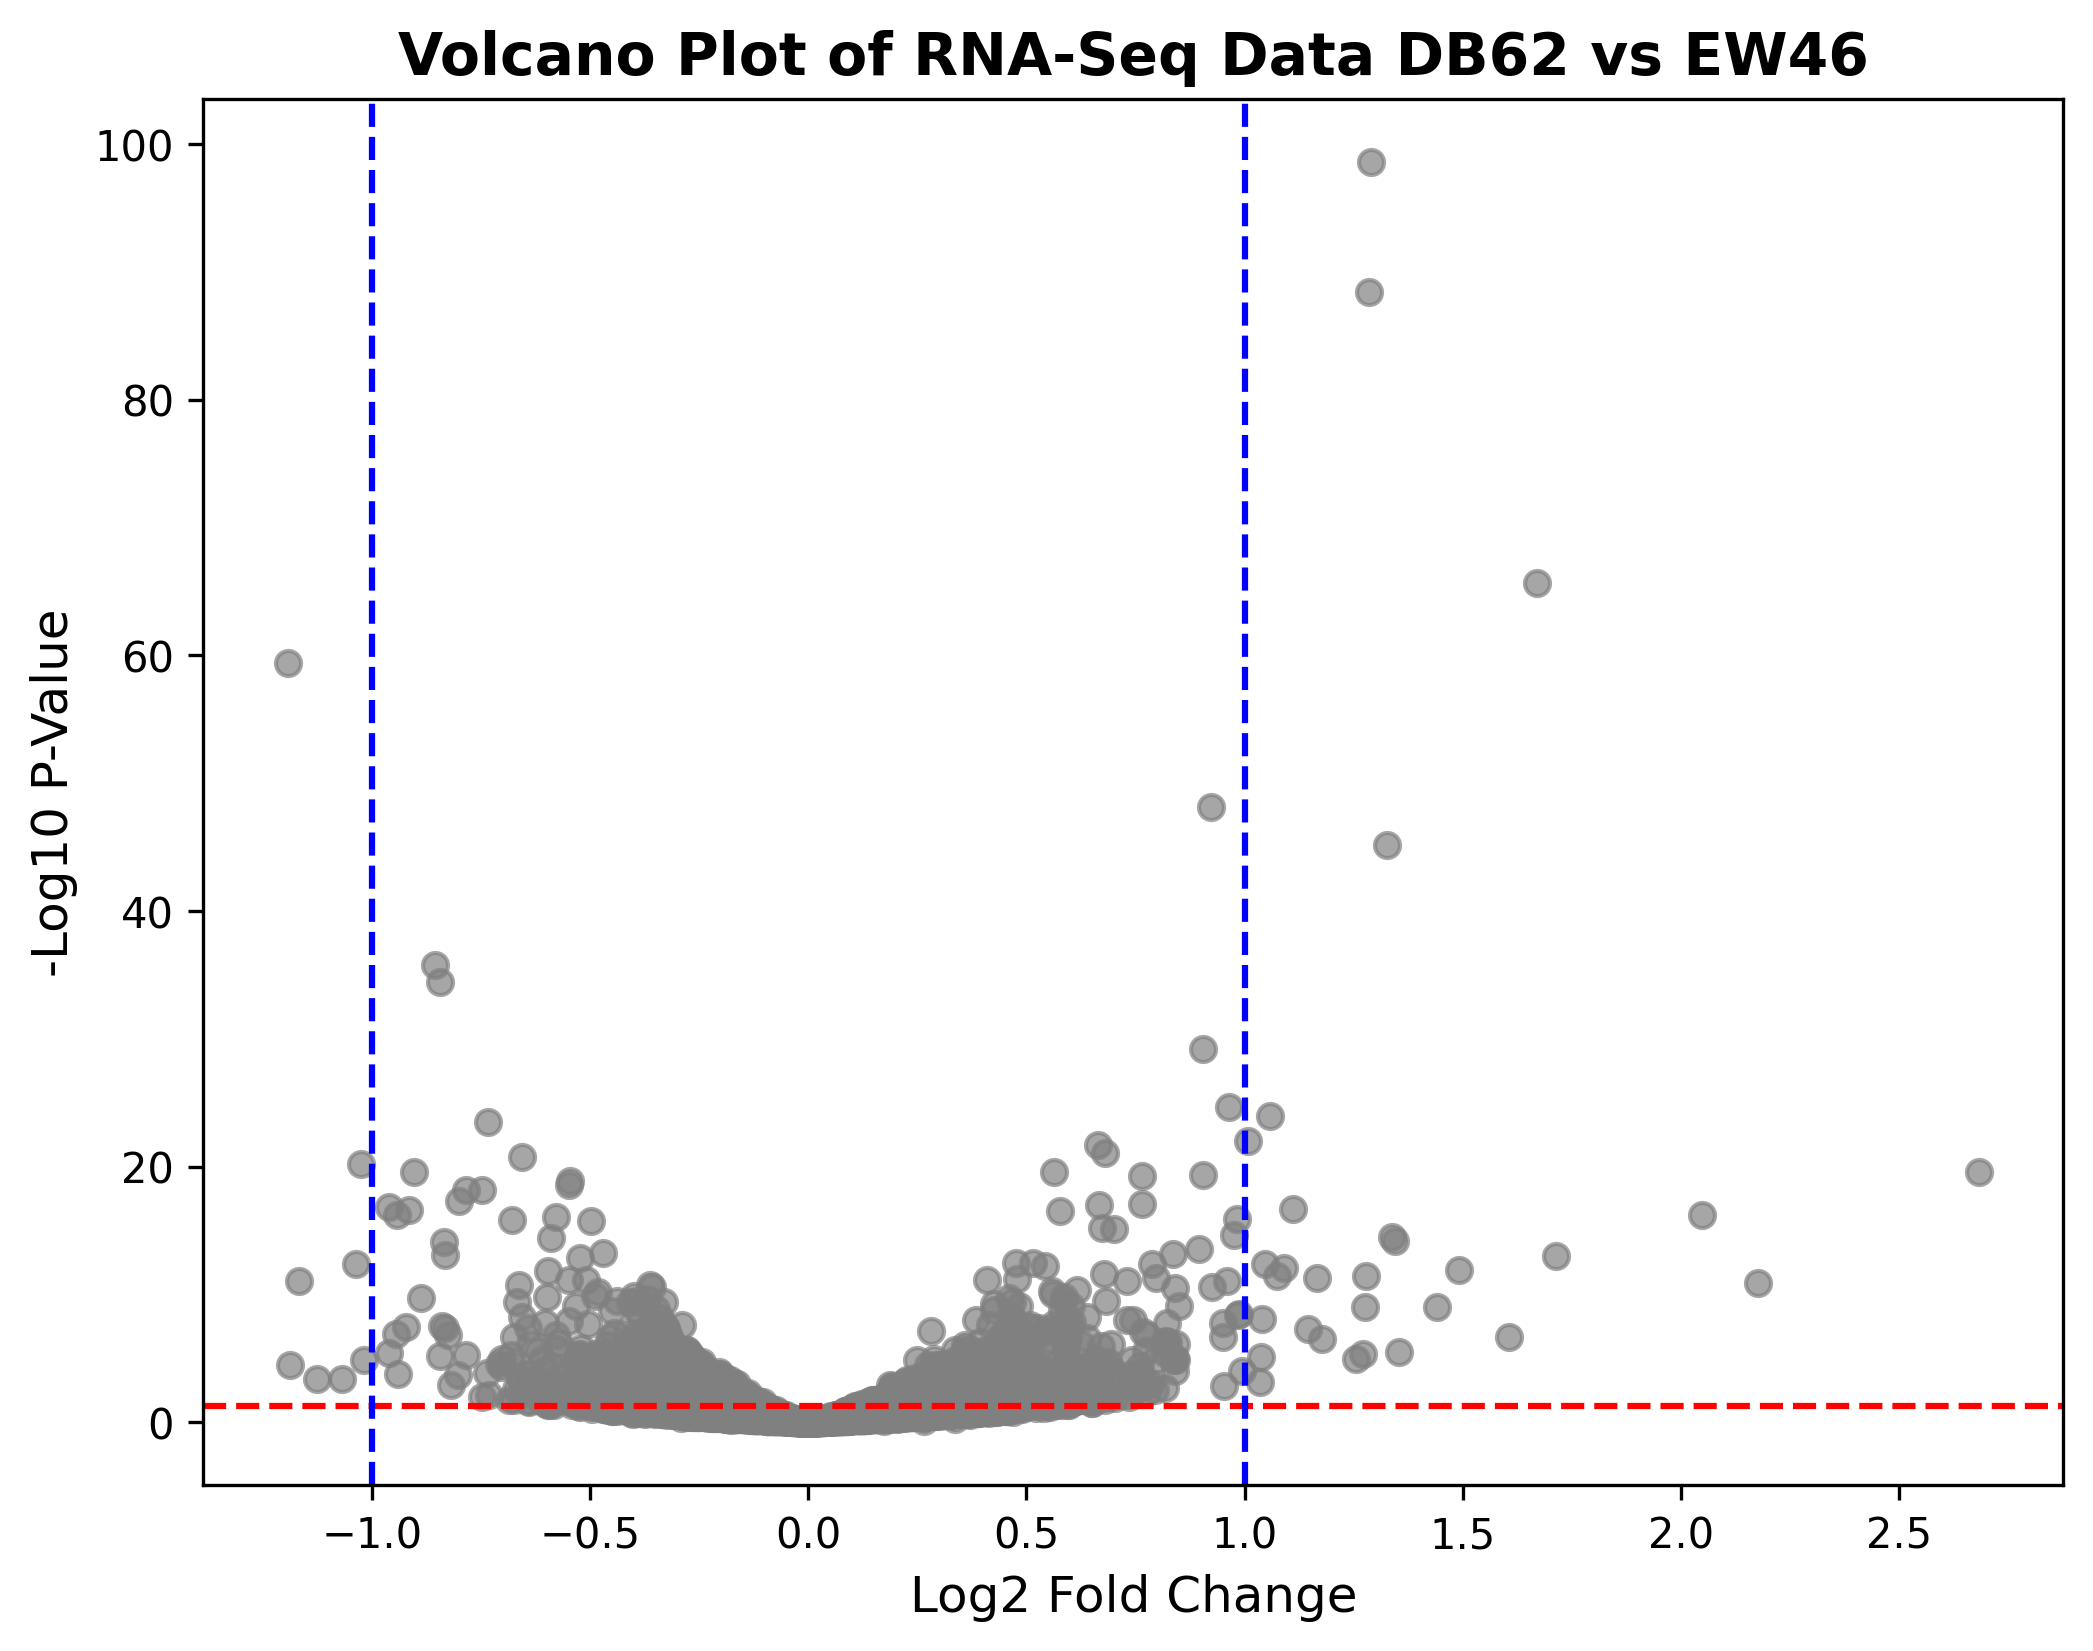

In [42]:
#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])
plt.scatter(volcanononsigfullfinal["log2FoldChange"], volcanononsigfullfinal["NegLog10Pvalue"], color = 'gray', alpha=0.7)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.show()

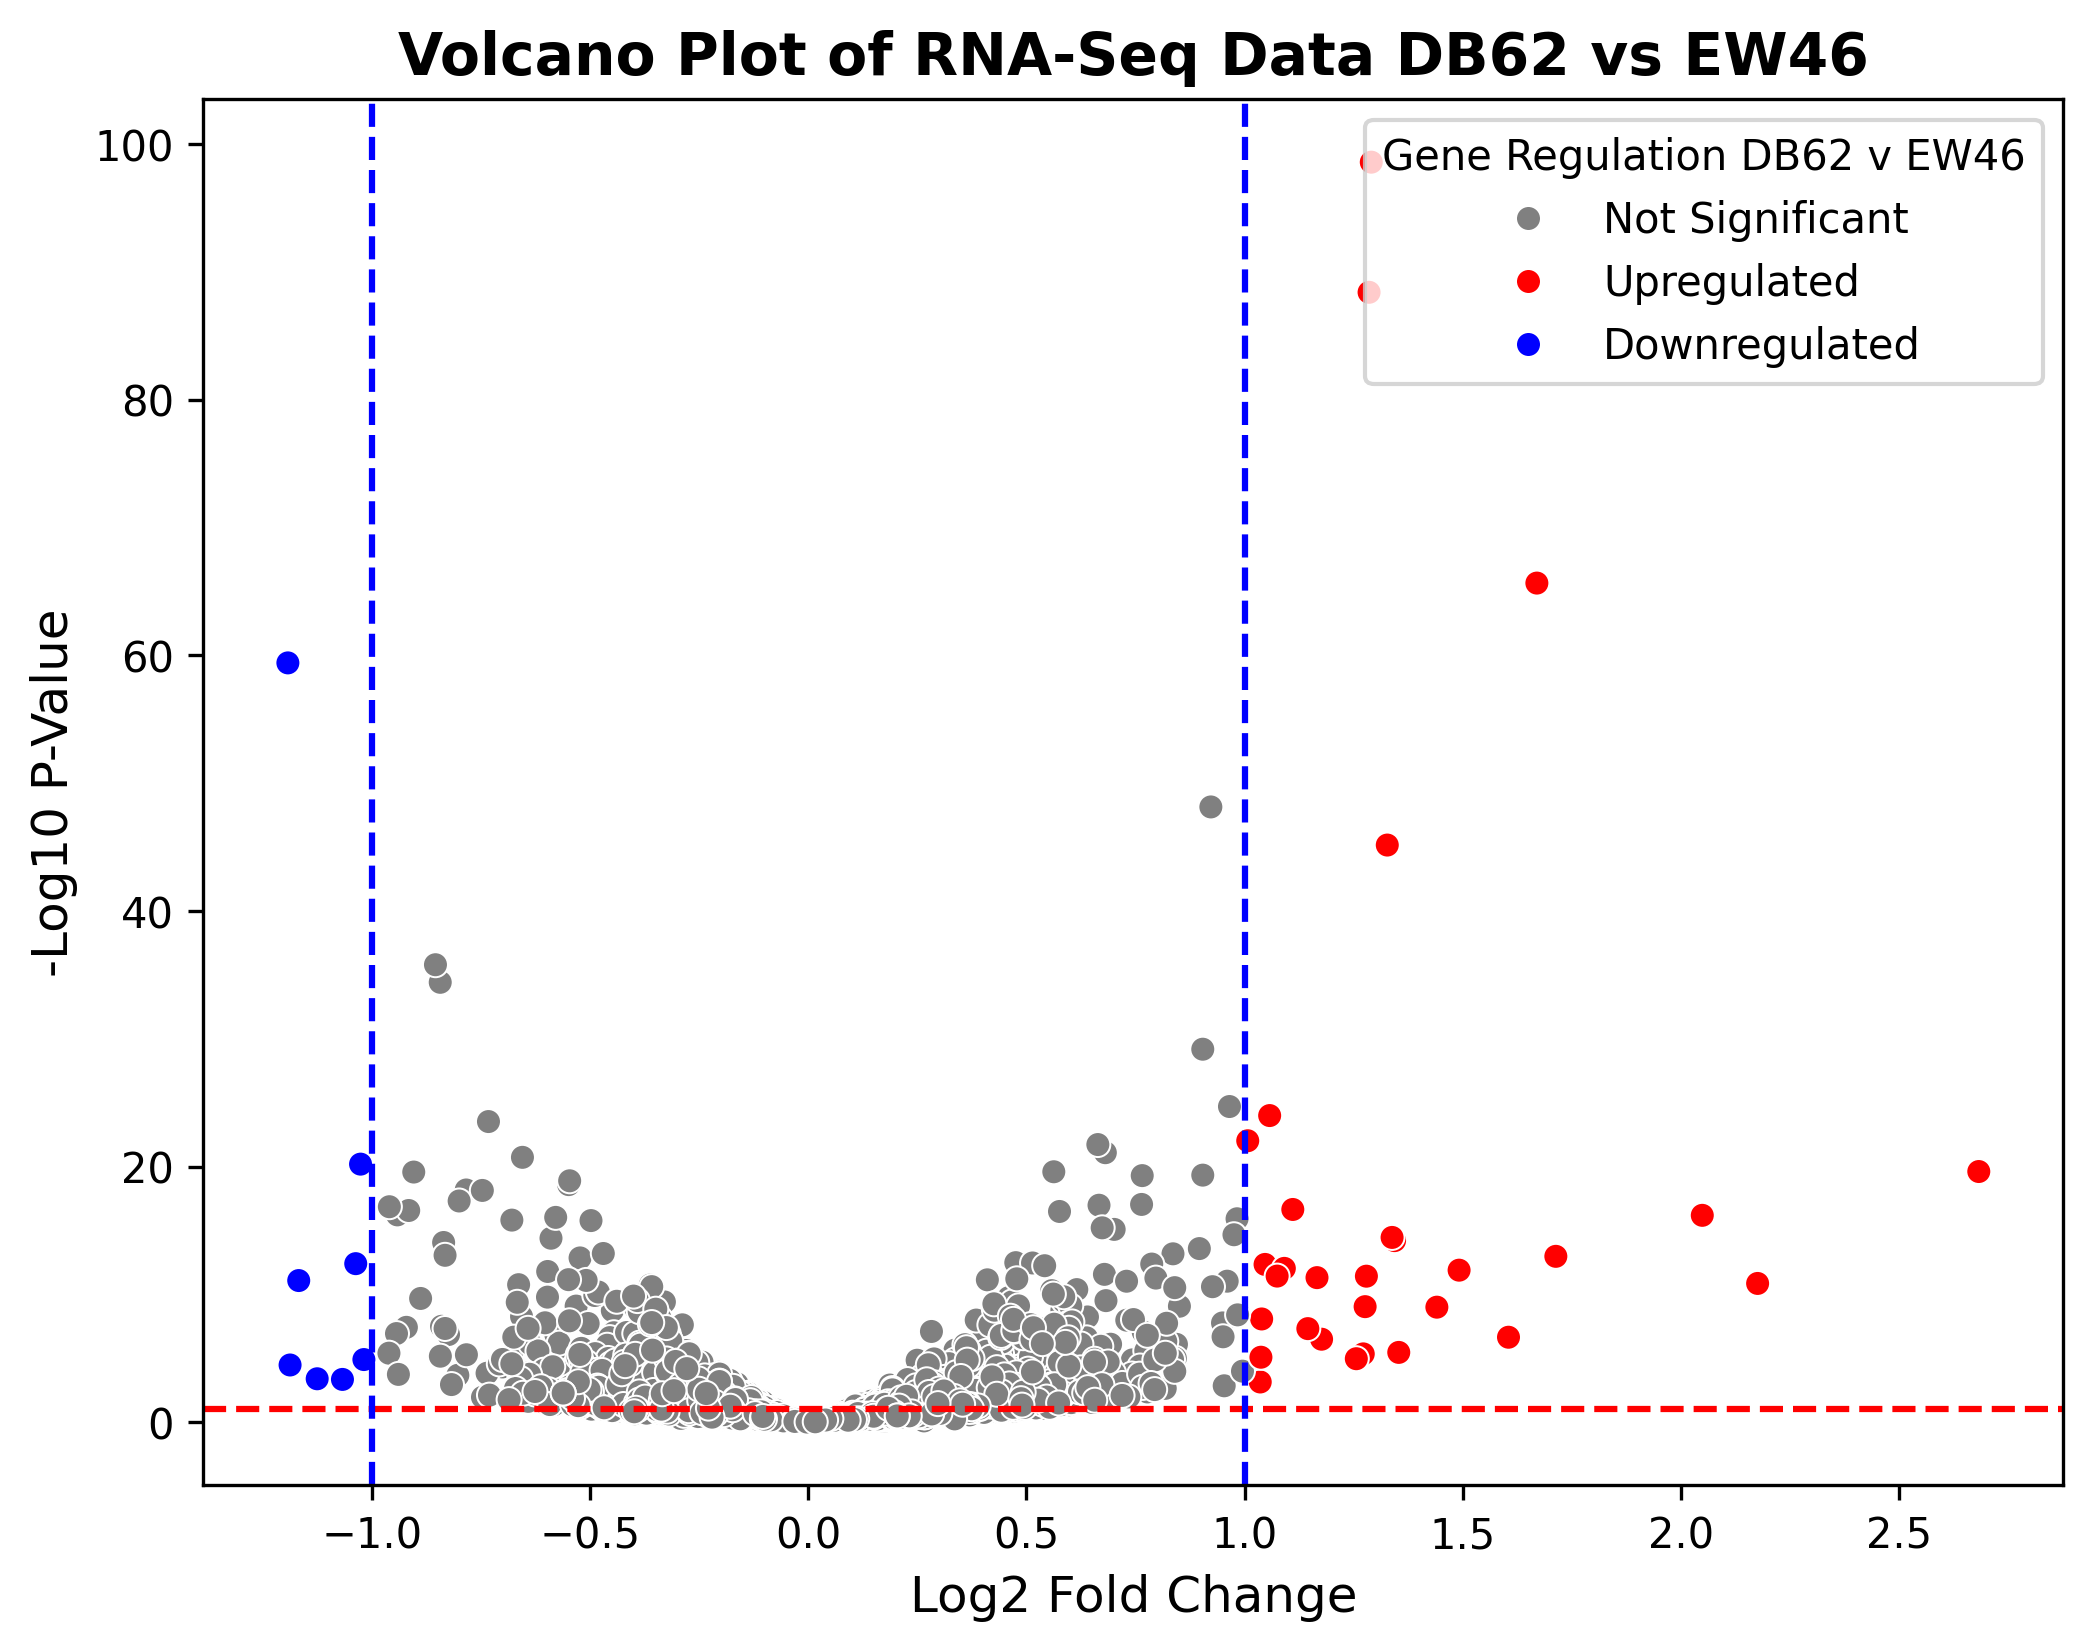

In [43]:
significant_genes = (volcanononsigfullfinal["pvalue"] < 0.05) & (abs(volcanononsigfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])

# Assign regulation status based on criteria
volcanononsigfullfinal["Regulation"] = "Not Significant" # Default
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#Set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(title="Gene Regulation DB62 v EW46", loc="upper right")
plt.savefig("volcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()

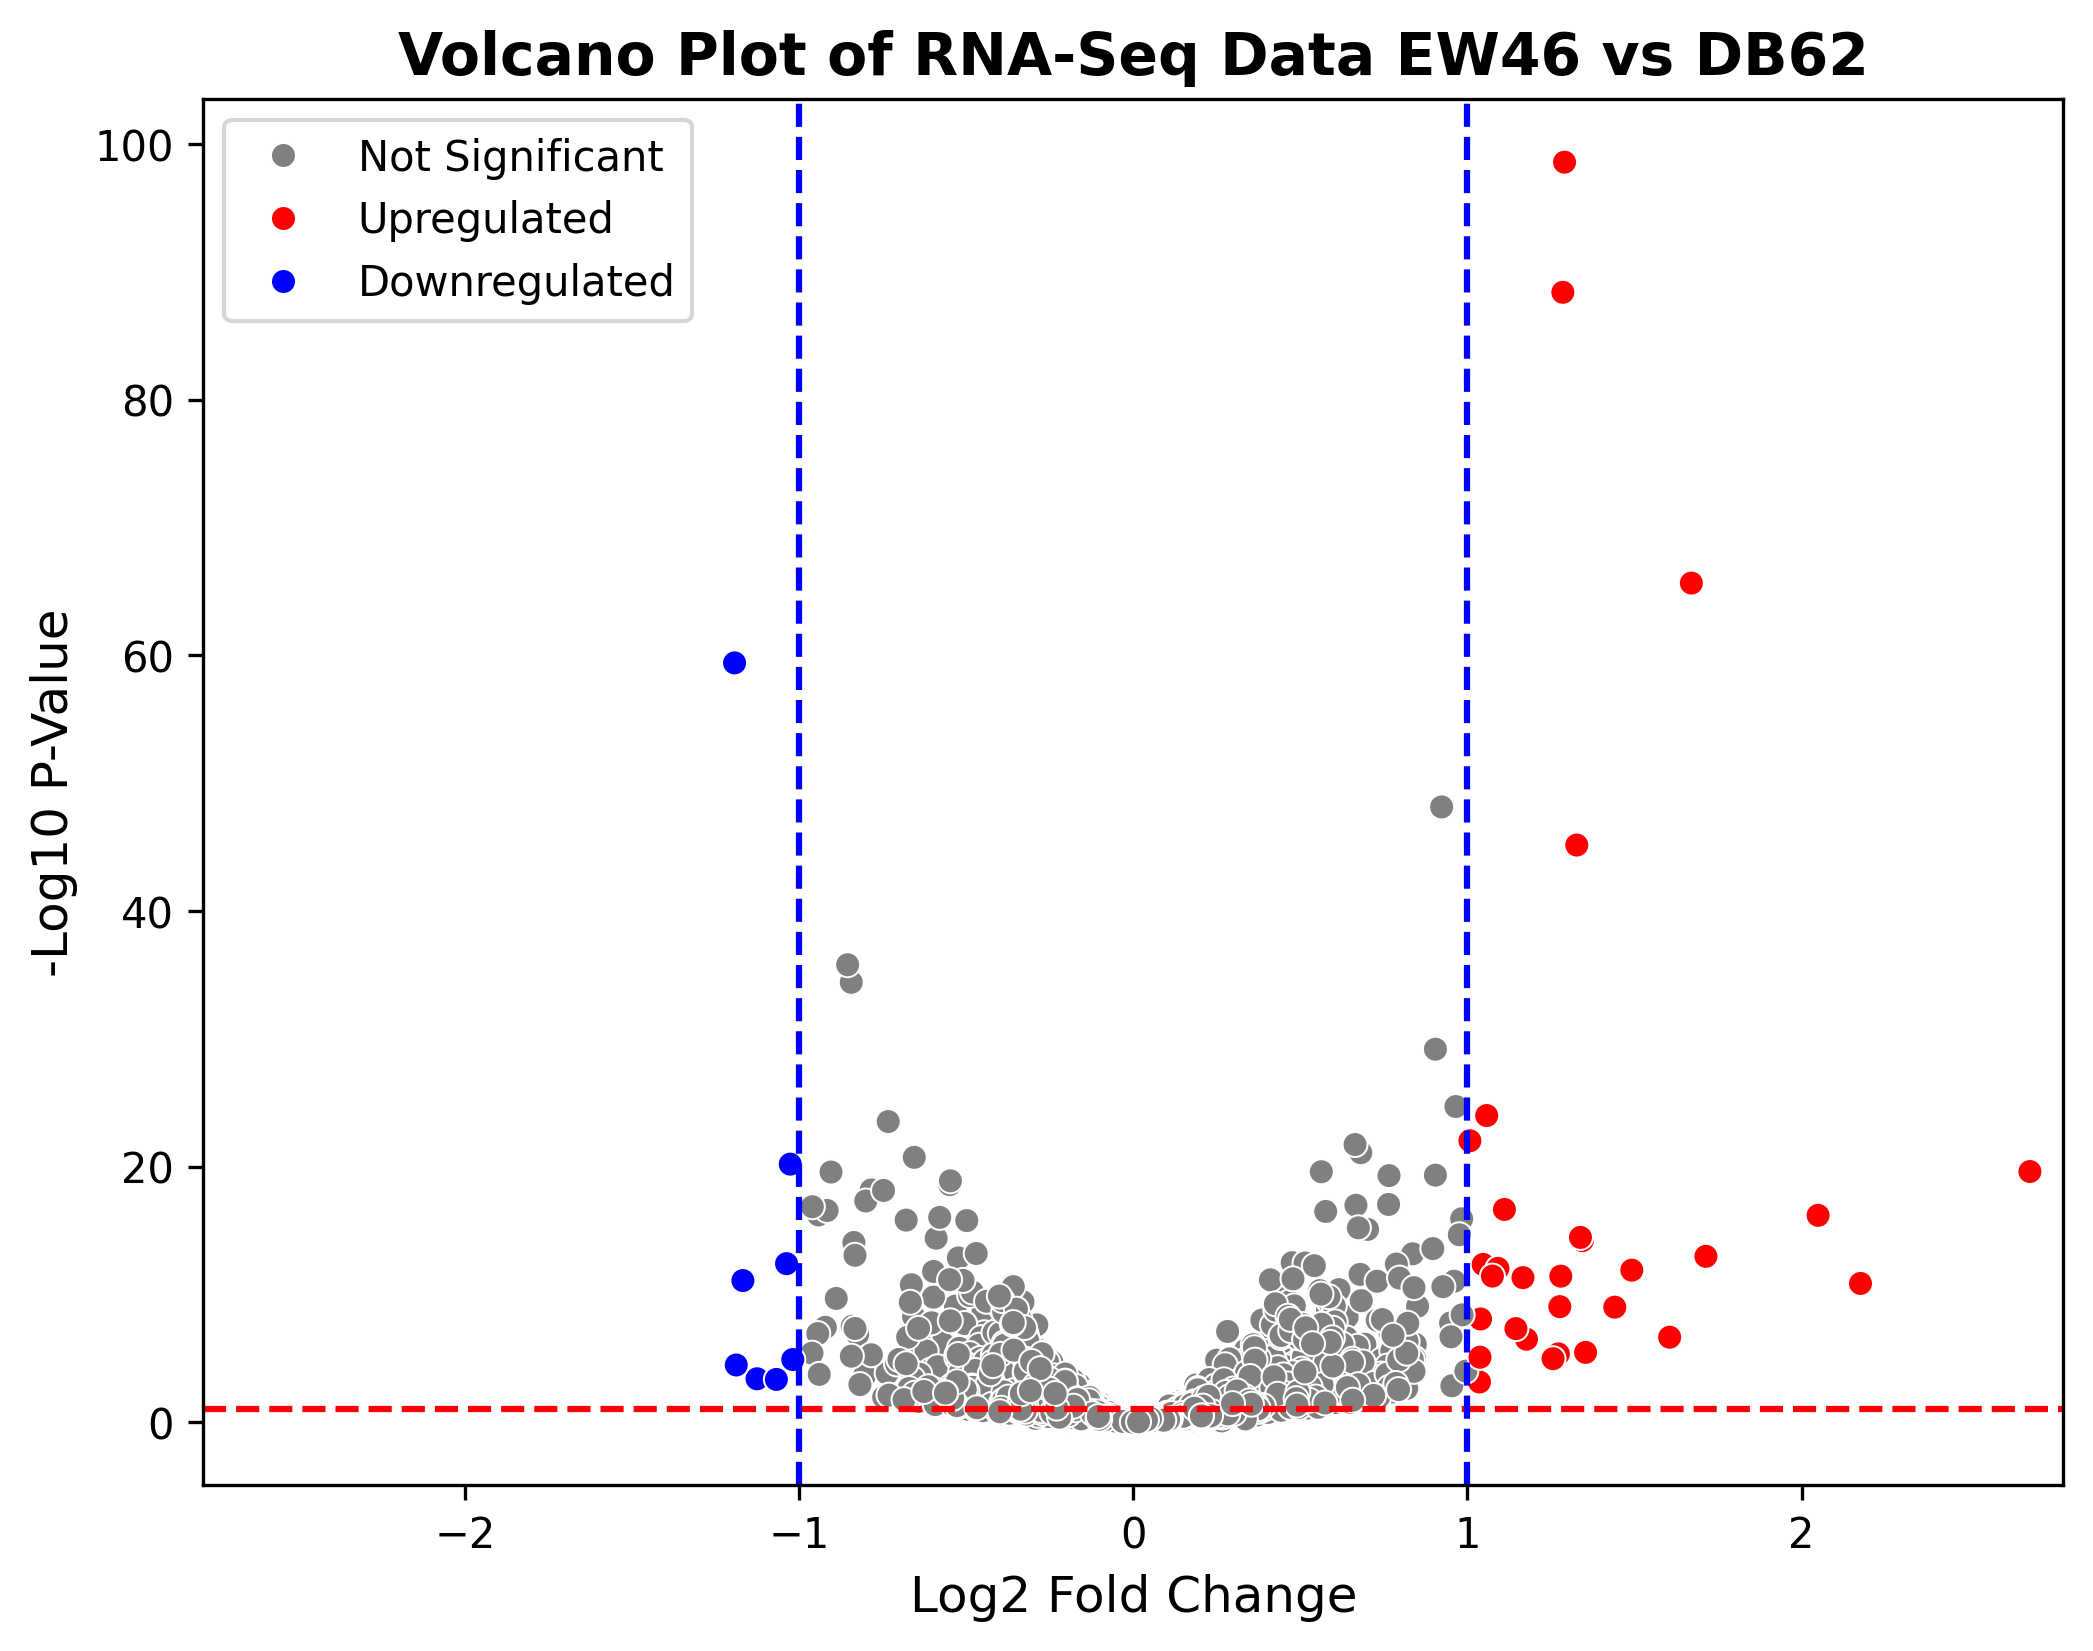

In [44]:
significant_genes = (volcanononsigfullfinal["pvalue"] < 0.05) & (abs(volcanononsigfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
volcanononsigfullfinal["NegLog10Pvalue"] = -np.log10(volcanononsigfullfinal["pvalue"])

# Assign regulation status based on criteria
volcanononsigfullfinal["Regulation"] = "Not Significant" # Default
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
volcanononsigfullfinal.loc[(volcanononsigfullfinal["pvalue"] < 0.05) & (volcanononsigfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#Set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data EW46 vs DB62", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(loc="upper left")
#plt.savefig("volcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
#Set Horizontal Axis to be Equal
max_abs_log2FoldChange = (volcanononsigfullfinal['log2FoldChange'].abs().max() + 0.1)
plt.xlim(-max_abs_log2FoldChange, max_abs_log2FoldChange)
plt.show()
#title="EW46 vs DB62"

In [45]:
from adjustText import adjust_text

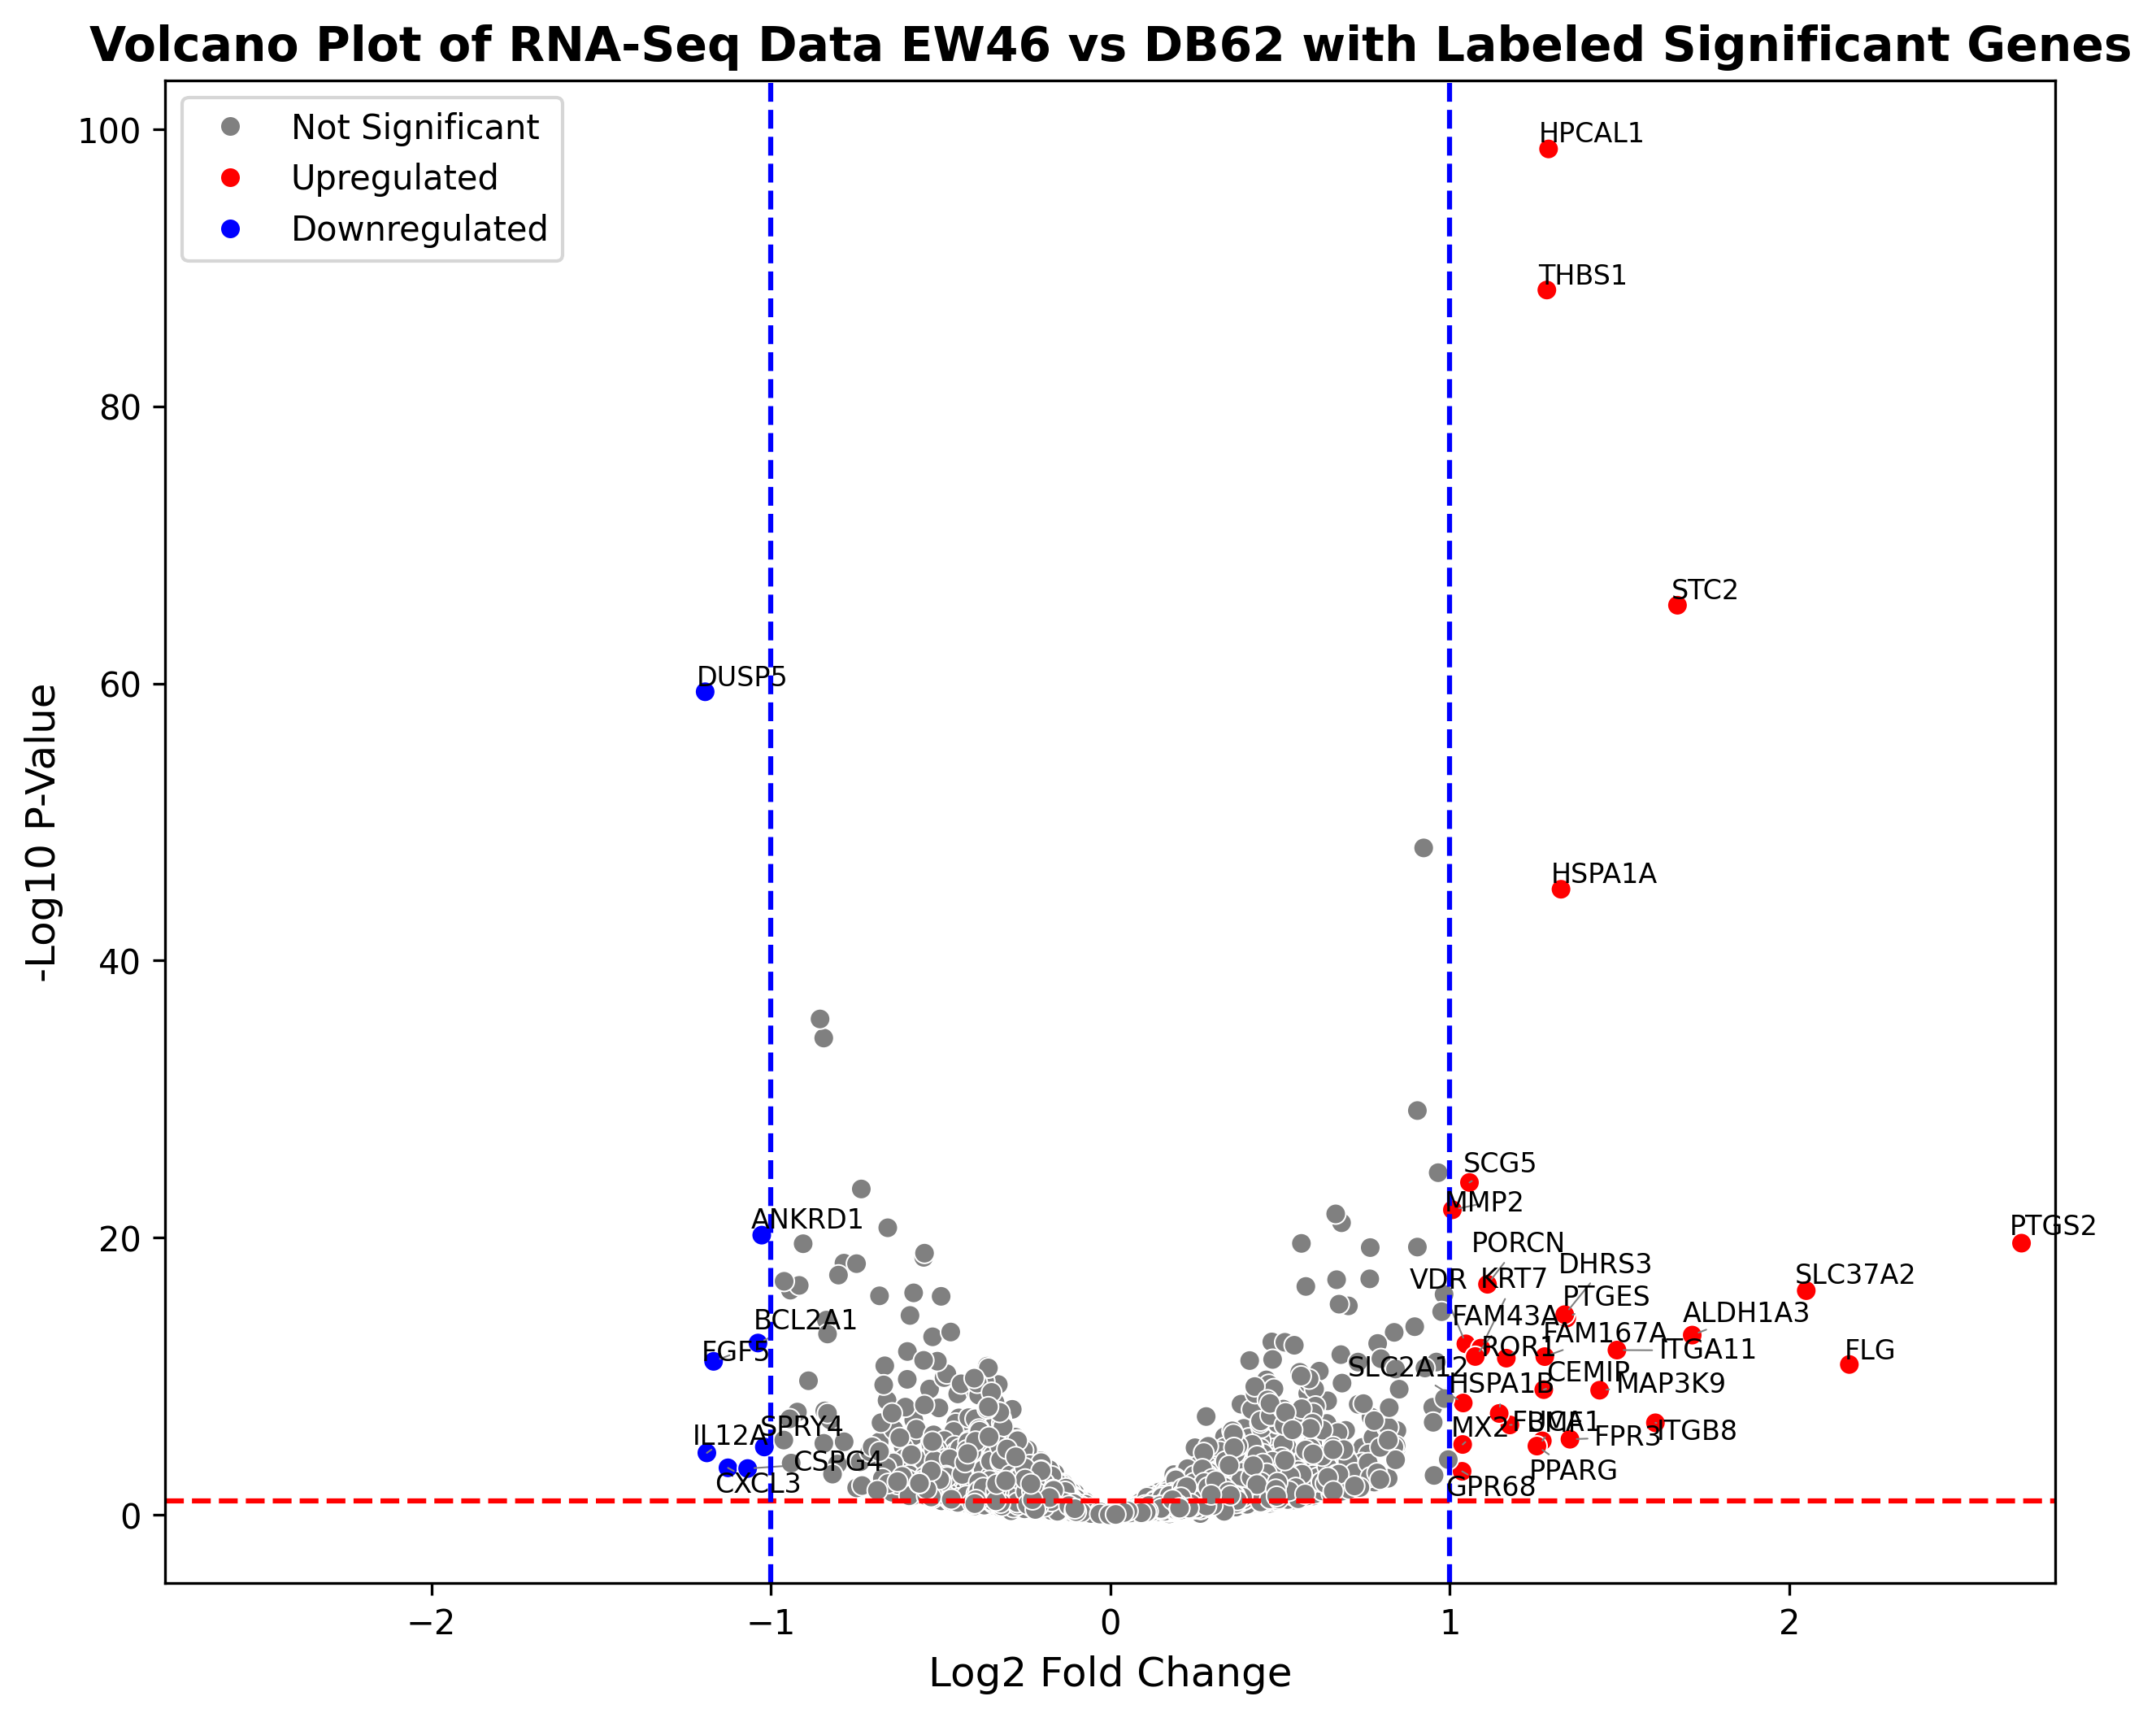

In [46]:
fig, ax = plt.figure(figsize=(10,8), dpi=300), plt.gca()
sns.scatterplot(data=volcanononsigfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette, ax=ax)

plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data EW46 vs DB62 with Labeled Significant Genes", fontsize=14, fontweight='bold')
plt.axhline(y=1, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.legend(loc="upper left")

# Filter for significant genes with 'Upregulated' or 'Downregulated' status
significant_labeled_genes = volcanononsigfullfinal[(volcanononsigfullfinal['Regulation'] == 'Upregulated') | (volcanononsigfullfinal['Regulation'] == 'Downregulated')]

# Create list of texts to adjust
texts = []
for i, row in significant_labeled_genes.iterrows():
    texts.append(plt.text(row['log2FoldChange'], row['NegLog10Pvalue'], row['Gene'], fontsize=8))

# Adjust text to prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

max_abs_log2FoldChange = (volcanononsigfullfinal['log2FoldChange'].abs().max() + 0.1)
plt.xlim(-max_abs_log2FoldChange, max_abs_log2FoldChange)
plt.savefig("volcano_plot_labeled_DB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()

In [47]:
#This volcano plot shows EW46 genes and if they are upregulated or downregulated compared to DB62.

# Heatmap with only significant genes

In [48]:
dds.layers["normed_counts"]

array([[ 207.89474391, 1619.02934998,   74.52830442, ...,   23.53525403,
         279.48114158,  251.04270963],
       [ 236.8879448 , 1842.05529275,   67.68226994, ...,   31.09725916,
         214.02231306,  214.02231306],
       [ 195.73300217, 1973.64110523,   72.85617303, ...,   28.27254476,
         225.0929525 ,  250.10328055],
       [ 178.27004486, 1935.50334419,   71.97237836, ...,   28.78895134,
         243.59881906,  219.23893716],
       [ 227.27467172, 1672.30489893,   58.55548311, ...,   21.83424794,
         244.14659059,  222.31234265],
       [ 156.0963283 , 1745.35777609,   70.28898994, ...,   19.16972453,
         232.77522641,  205.38990566]])

In [49]:
dds.layers["log1p"] = np.log1p(dds.layers["normed_counts"])

In [50]:
dds.layers["log1p"]

array([[5.34183051, 7.39019955, 4.32450748, ..., 3.20011102, 5.63650649,
        5.52959856],
       [5.47179974, 7.51917996, 4.22949109, ..., 3.46877064, 5.3707418 ,
        5.3707418 ],
       [5.28184749, 7.58814194, 4.30211959, ..., 3.37665004, 5.42094621,
        5.52586433],
       [5.1888933 , 7.56863923, 4.29008099, ..., 3.39413756, 5.4996194 ,
        5.39471303],
       [5.4305496 , 7.42255593, 4.08690837, ..., 3.12826151, 5.50185636,
        5.40857143],
       [5.05685917, 7.46528763, 4.2667419 , ..., 3.00418269, 5.45436008,
        5.32976713]])

In [51]:
#This is the dataframe where we'll use all the remaining genes
cleanedsigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.353876,1.441036,0.235931,6.107862,1.009745e-09,9.545390e-08,MAP3K9
ENSG00000073756,82.628921,2.683645,0.290448,9.239676,2.472458e-20,1.371721e-17,PTGS2
ENSG00000087245,817.719389,1.007352,0.102630,9.815354,9.669814e-23,7.523859e-20,MMP2
ENSG00000102312,411.707172,1.110692,0.131013,8.477740,2.296110e-17,7.037925e-15,PORCN
ENSG00000103888,134.455975,1.276518,0.208484,6.122846,9.191872e-10,8.771301e-08,CEMIP
ENSG00000104081,76.550502,1.272250,0.277528,4.584214,4.556970e-06,1.896862e-04,BMF
ENSG00000105855,61.541765,1.605297,0.310151,5.175850,2.268758e-07,1.334214e-05,ITGB8
ENSG00000111424,287.505466,1.047067,0.144672,7.237550,4.568638e-13,7.832505e-11,VDR
ENSG00000113739,956.432891,1.670333,0.097065,17.208405,2.296715e-66,7.743758e-63,STC2


In [52]:
dds_sigs1 = dds[:,cleanedsigs.index]
dds_sigs1

View of AnnData object with n_obs × n_vars = 6 × 38
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [53]:
heatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)

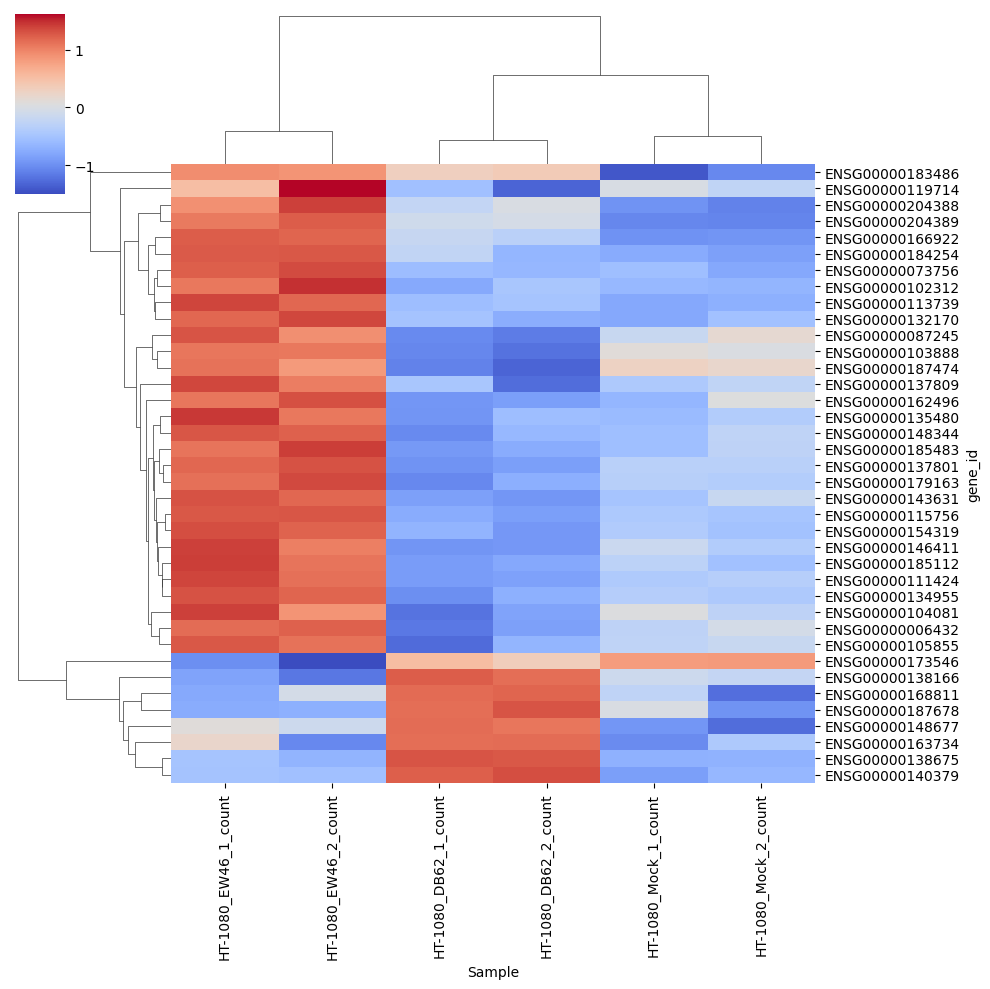

In [54]:
sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm")

In [55]:
heatmapfull.index = heatmapfull.index.map(mapper.mapper)

In [56]:
#if you want to make a CSV list of genes
#heatmapfull
#heatmapfull.to_csv('heatmap.csv')

'DB62 V EW46'

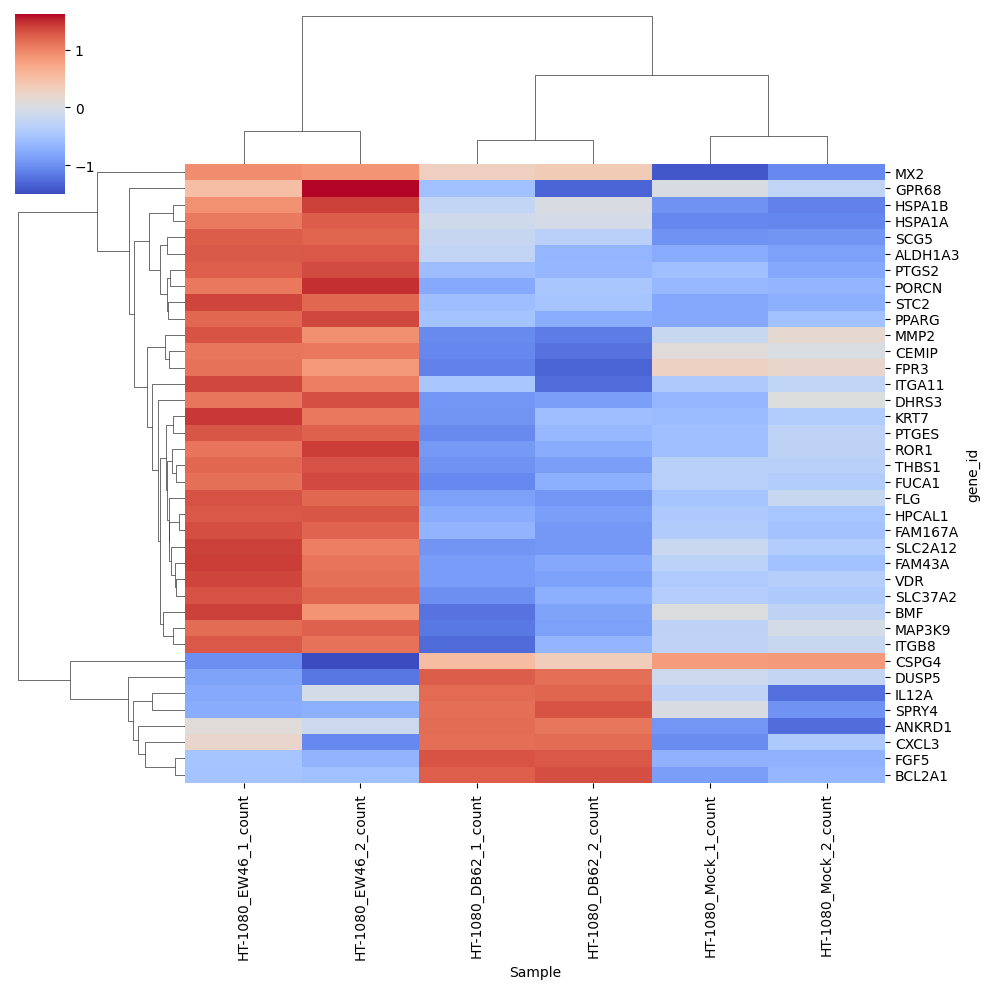

In [57]:
labeledheatmapfull = sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''DB62 V EW46'''

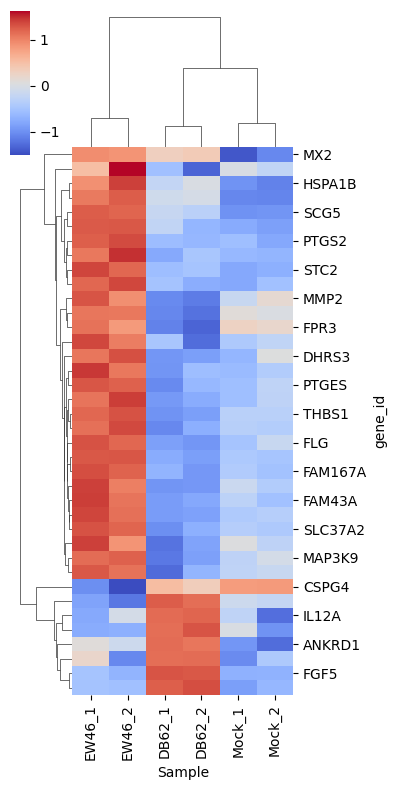

In [58]:
finalheatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)
finalheatmapfull.index = finalheatmapfull.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
finalheatmapfull.rename(columns=rename_map, inplace=True)

finallabeledheatmapfull = sns.clustermap(finalheatmapfull, z_score=0, cmap = "coolwarm", figsize=(4,8))
finallabeledheatmapfull

# Top 24 significant genes Heatmap

In [59]:
# Keep top 24 genes by lowest and highest log2foldchanges
top_12_lowest_lfc = cleanedsigs.nsmallest(12, 'log2FoldChange')
top_12_highest_lfc = cleanedsigs.nlargest(12, 'log2FoldChange')
top_24_genes_for_plots = pd.concat([top_12_lowest_lfc, top_12_highest_lfc])
top_24_genes_for_plots # Will use this dataframe for the top volcano plot as well

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000138166,3455.263482,-1.193566,0.072979,-16.354826,4.018567e-60,1.016195e-56,DUSP5
ENSG00000168811,76.061169,-1.188536,0.286586,-4.147220,3.365368e-05,1.029903e-03,IL12A
ENSG00000138675,187.939076,-1.168681,0.171050,-6.832391,8.351105e-12,1.157143e-09,FGF5
ENSG00000163734,62.807415,-1.126374,0.318342,-3.538252,4.027860e-04,8.197547e-03,CXCL3
ENSG00000173546,64.800738,-1.068431,0.304622,-3.507394,4.525181e-04,9.045890e-03,CSPG4
ENSG00000140379,279.832646,-1.037973,0.143046,-7.256235,3.980138e-13,7.062999e-11,BCL2A1
ENSG00000148677,666.209824,-1.026940,0.109469,-9.381135,6.526652e-21,3.883358e-18,ANKRD1
ENSG00000187678,107.556046,-1.019275,0.233449,-4.366161,1.264491e-05,4.503635e-04,SPRY4
ENSG00000087245,817.719389,1.007352,0.102630,9.815354,9.669814e-23,7.523859e-20,MMP2


In [60]:
dds_sigs = dds[:,top_24_genes_for_plots.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 24
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [61]:
smallheatmap = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)

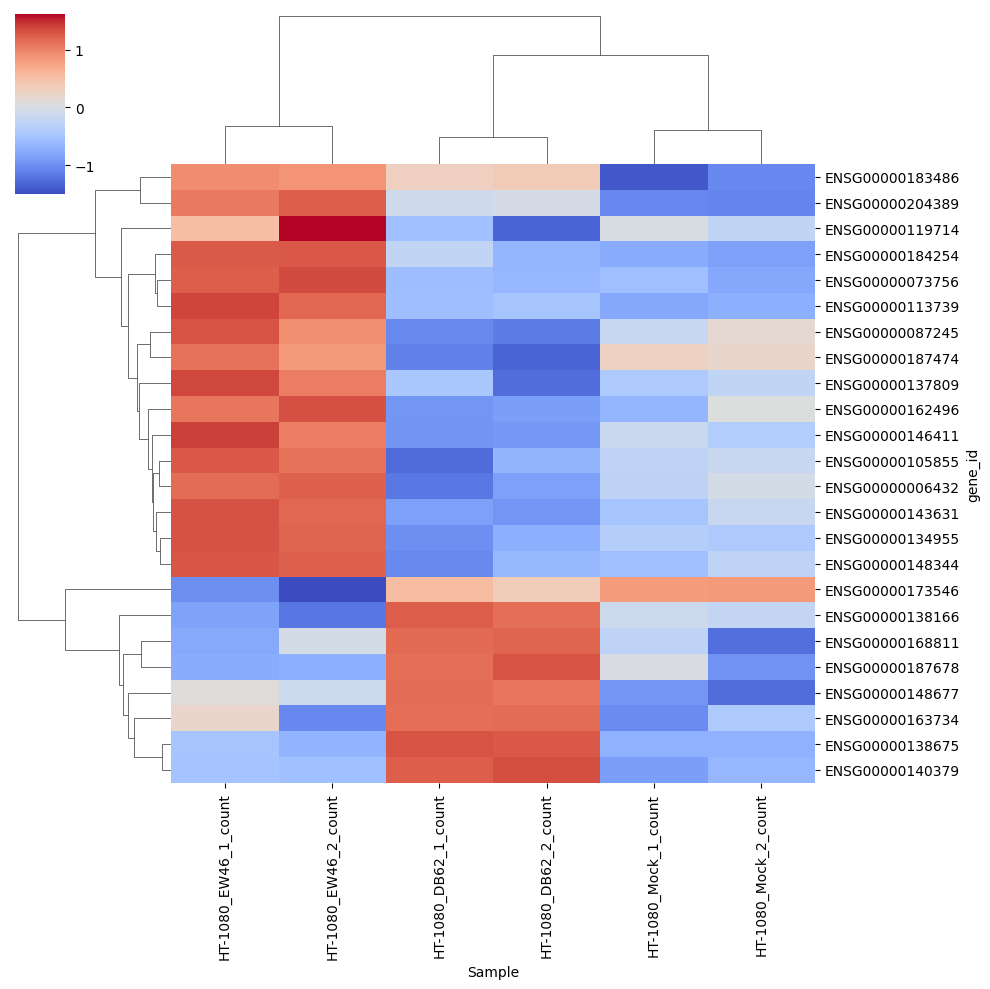

In [62]:
sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm")

In [63]:
smallheatmap.index = smallheatmap.index.map(mapper.mapper)

In [64]:
#smallheatmap
#smallheatmap.to_csv('smallheatmap.csv')
#again only neccesary if you want a csv

'DB62 V EW46'

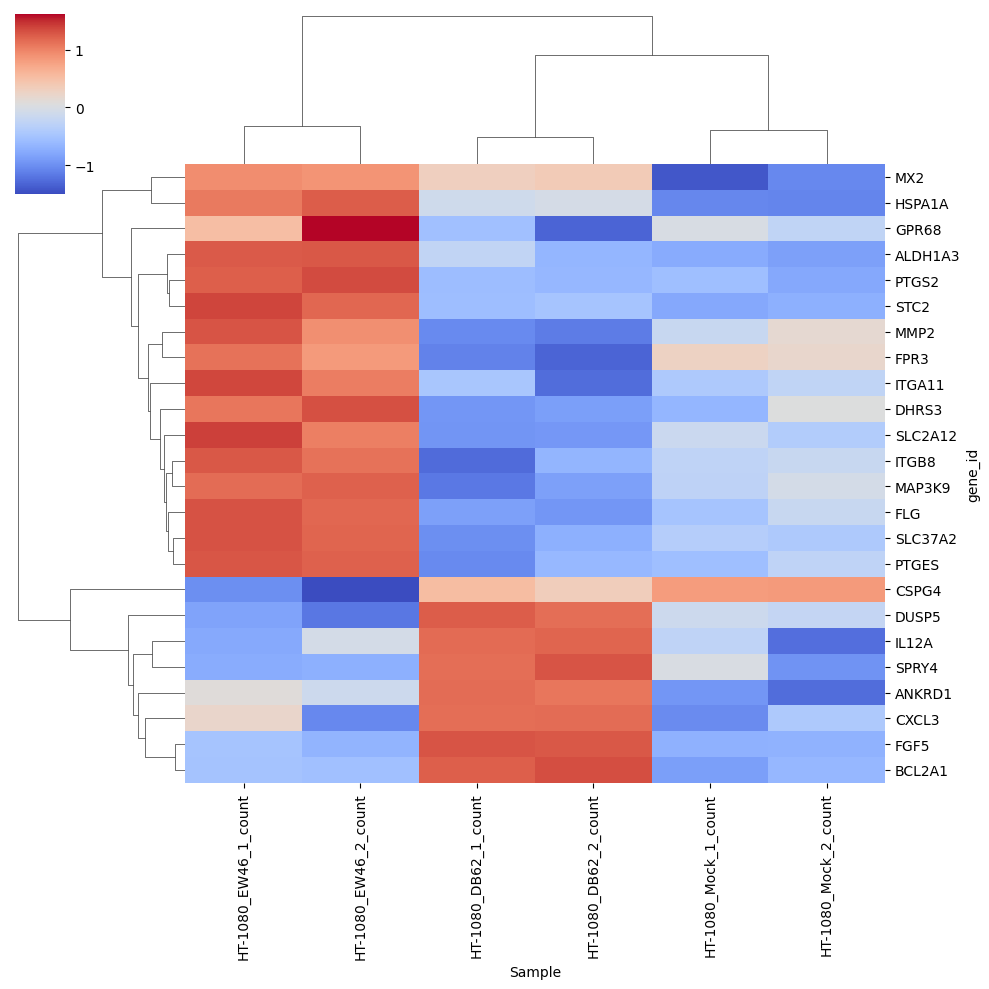

In [65]:
labeledheatmapsmall = sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''DB62 V EW46'''

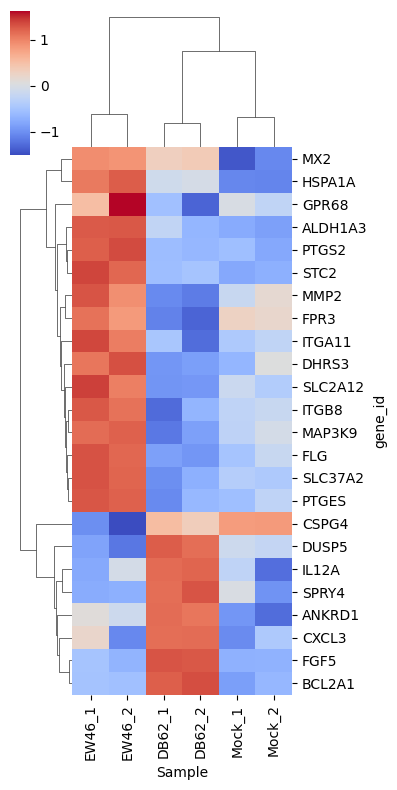

In [66]:
smallheatmap_1 = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)
smallheatmap_1.index = smallheatmap_1.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
smallheatmap_1.rename(columns=rename_map, inplace=True)

smallheatmaplabeledfinal = sns.clustermap(smallheatmap_1, z_score=0, cmap = "coolwarm", figsize=(4,8))
smallheatmaplabeledfinal

## Ranking by absolute log2fold change to see if a diff appears

In [67]:
cleanedsigs['abs_log2FoldChange'] = cleanedsigs['log2FoldChange'].abs()
top_24_genes_by_abs_lfc = cleanedsigs.nlargest(24, 'abs_log2FoldChange')
top_24_genes_by_abs_lfc

/tmp/ipykernel_6077/1343828780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleanedsigs['abs_log2FoldChange'] = cleanedsigs['log2FoldChange'].abs()


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,abs_log2FoldChange
gene_id,,,,,,,,
ENSG00000073756,82.628921,2.683645,0.290448,9.239676,2.472458e-20,1.371721e-17,PTGS2,2.683645
ENSG00000143631,61.670152,2.176508,0.322100,6.757252,1.406339e-11,1.871726e-09,FLG,2.176508
ENSG00000134955,104.880458,2.049608,0.245348,8.353876,6.605842e-17,1.805894e-14,SLC37A2,2.049608
ENSG00000184254,110.596656,1.713835,0.230581,7.432676,1.064225e-13,2.031063e-11,ALDH1A3,1.713835
ENSG00000113739,956.432891,1.670333,0.097065,17.208405,2.296715e-66,7.743758e-63,STC2,1.670333
ENSG00000105855,61.541765,1.605297,0.310151,5.175850,2.268758e-07,1.334214e-05,ITGB8,1.605297
ENSG00000137809,155.591664,1.492011,0.210270,7.095683,1.287138e-12,2.099904e-10,ITGA11,1.492011
ENSG00000006432,105.353876,1.441036,0.235931,6.107862,1.009745e-09,9.545390e-08,MAP3K9,1.441036
ENSG00000187474,69.362194,1.353659,0.291743,4.639894,3.485875e-06,1.539722e-04,FPR3,1.353659


In [68]:
dds_sigs = dds[:,top_24_genes_by_abs_lfc.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 24
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [69]:
rankedsmallheatmap = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)

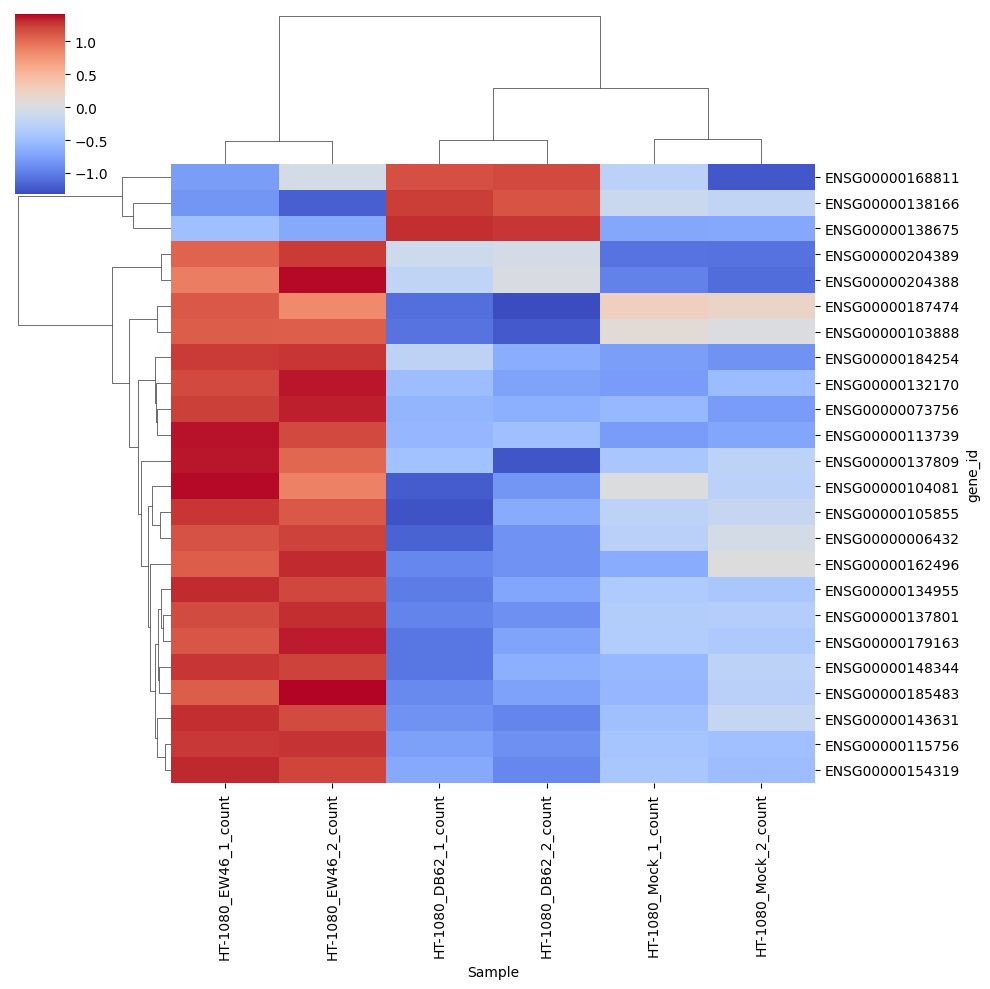

In [70]:
sns.clustermap(rankedsmallheatmap, z_score=0, cmap = "coolwarm")

In [71]:
rankedsmallheatmap.index = rankedsmallheatmap.index.map(mapper.mapper)

'Mock V DB62'

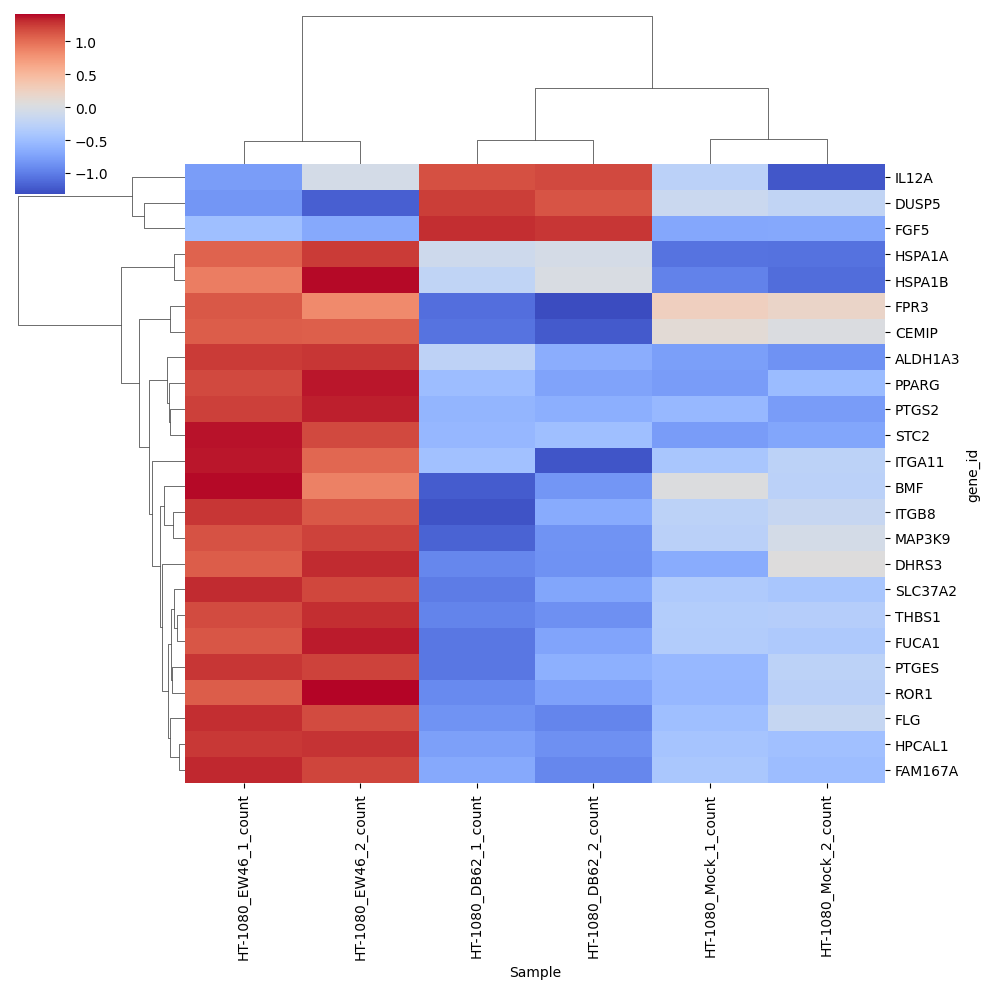

In [72]:
ranklabeledheatmapsmall = sns.clustermap(rankedsmallheatmap, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''Mock V DB62'''

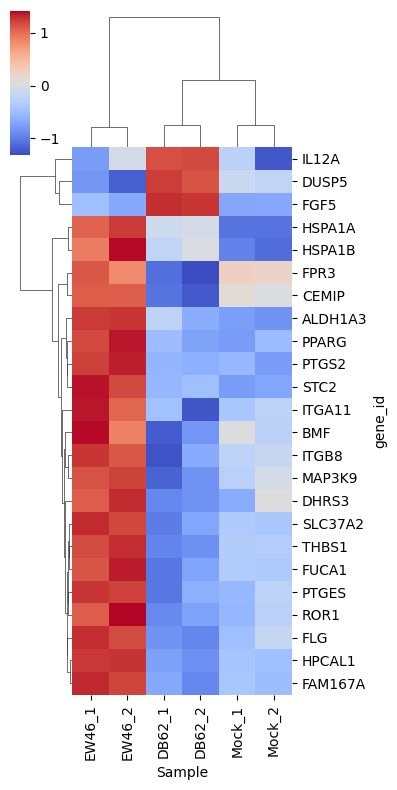

In [73]:
ranksmallheatmap_1 = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)
ranksmallheatmap_1.index = ranksmallheatmap_1.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
ranksmallheatmap_1.rename(columns=rename_map, inplace=True)

ranksmallheatmaplabeledfinal = sns.clustermap(ranksmallheatmap_1, z_score=0, cmap = "coolwarm", figsize=(4,8))
ranksmallheatmaplabeledfinal